TASK 4: Adaptive and Kalman Filtering

In [7]:
from datetime import datetime
import time

import neurokit2 as nk
import numpy as np
import matplotlib.pyplot as plt
import scipy
from matplotlib.ticker import MaxNLocator
from datetime import timedelta

# Import Pandas only for reading Watch CSV File and for plotting description in Q1
import pandas as pd


def load_bp_csv(filename, start_datetime):
    test = pd.read_csv(filename, skiprows=8, header=1, delimiter='\t')
    test = test.drop(0)
    test = test.drop(test.columns[3], axis=1)  # Drop the first column
    test = test.rename(columns={'CH9': 'ecg', 'CH1': 'ppg'})
    test['ppg'] = pd.to_numeric(test['ppg'], errors='coerce')
    # if 'min' in test.columns, create new milli sec column
    if 'min' in test.columns:
        # Convert 'min' to milliseconds
        test['time_ms'] = test['min'] * 60 * 1000
    else:
        test = test.rename(columns={'milliSec': 'time_ms'})
    test['ecg'] = pd.to_numeric(test['ecg'], errors='coerce')
    test['timestamp'] = pd.to_datetime(start_datetime) + pd.to_timedelta(test['time_ms'], unit='ms')
    return test


def load_watch_ecg(filename):
    df = pd.read_csv(filename, skiprows=2)
    df = df[['Timestamp', 'ECG data']].dropna()
    df.rename(columns={'Timestamp': 'timestamp', 'ECG data': 'ecg'}, inplace=True)
    df['timestamp'] = pd.to_numeric(df['timestamp'], errors='coerce')
    df['ecg'] = pd.to_numeric(df['ecg'], errors='coerce')
    df = df.dropna()

    # Convert to seconds
    df['time_ms'] = (df['timestamp'] - df['timestamp'].iloc[0])
    return df


def load_watch_data(ecg_file, ppg_file):
    ecg_df = pd.read_csv(ecg_file, skiprows=2)
    ppg_df = pd.read_csv(ppg_file, skiprows=2)

    # Rename columns for clarity
    ecg_df.rename(columns={'Timestamp': 'timestamp', 'ECG data': 'ecg'}, inplace=True)
    ppg_df.rename(columns={'PPG Timestamp': 'timestamp', 'PPG data': 'ppg'}, inplace=True)

    latest_start_time = max(ecg_df['timestamp'].iloc[0], ppg_df['timestamp'].iloc[0])
    earliest_end_time = min(ecg_df['timestamp'].iloc[-1], ppg_df['timestamp'].iloc[-1])

    # Filter data to the common time range
    ecg_df = ecg_df[(ecg_df['timestamp'] >= latest_start_time) & (ecg_df['timestamp'] <= earliest_end_time)]
    ppg_df = ppg_df[(ppg_df['timestamp'] >= latest_start_time) & (ppg_df['timestamp'] <= earliest_end_time)]

    # Drop all columns except timestamp, time_ms and ecg/ppg
    ppg_df = ppg_df.drop(columns=['ADXL Timestamp'])
    ecg_df = ecg_df.drop(columns=['Seq No.'])
    # Merge ECG and PPG based on the millisecond given
    merged_df = pd.merge_asof(ecg_df.sort_values('timestamp'), ppg_df.sort_values('timestamp'), on='timestamp',
                              direction='nearest')

    merged_df['timestamp'] = pd.to_datetime(merged_df['timestamp'], unit='ms')
    return merged_df


def plot_watch_bp_ecg(watch_df, bp_data, start_time, end_time, dataset_name='Recording', vlines=[], vlines_name=[]):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    watch_df.sort_values('timestamp', inplace=True)
    bp_data.sort_values('time_ms', inplace=True)

    # Select time frame to plot
    # Discard time frames that are not represented in both recordings
    latest_start_time = max(watch_df['timestamp'].iloc[0], bp_data['timestamp'].iloc[0])  # + timedelta(minutes=5)
    earliest_end_time = min(watch_df['timestamp'].iloc[-1], bp_data['timestamp'].iloc[-1])
    watch_df = watch_df[(watch_df['timestamp'] >= latest_start_time) & (watch_df['timestamp'] <= earliest_end_time)]
    watch_df = watch_df[(watch_df['timestamp'] >= start_time) & (watch_df['timestamp'] <= end_time)]
    bp_data = bp_data[(bp_data['timestamp'] >= latest_start_time) & (bp_data['timestamp'] <= earliest_end_time)]
    bp_data = bp_data[(bp_data['timestamp'] >= start_time) & (bp_data['timestamp'] <= end_time)]
    watch_df = watch_df.dropna()
    # Plot ECG from Watch
    ax1.plot(watch_df['timestamp'], watch_df['PPG'], label='PPG from Watch', color='blue')
    ax1.set_ylabel('ECG Amplitude')
    ax1.set_xlabel('Time')
    ax1.set_title(f'{dataset_name} - PPG Signal from Smartwatch')

    # Plot ECG from BioPac
    ax2.plot(bp_data['timestamp'], bp_data['ecg'], label='ECG from BioPac', color='orange')
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel('ECG Amplitude')
    ax2.set_title(f'{dataset_name} - ECG Signal from BioPac')
    ax1.legend()
    ax2.legend()
    for vline, vline_name in zip(vlines, vlines_name):
        ax1.axvline(x=vline, color='red', linestyle='--', label=vline_name)
        ax2.axvline(x=vline, color='red', linestyle='--', label=vline_name)
    #ax1.legend()
    #ax2.legend()
    plt.tight_layout()
    plt.show()
    bp_data['ppg']
    fig, ax3 = plt.subplots(figsize=(12, 4))
    ax3.plot(bp_data['timestamp'], bp_data['ppg'], label='PPG from BioPac', color='orange')
    ax3.set_xlabel('Time')
    ax3.set_ylabel('ECG Amplitude')
    ax3.set_title(f'{dataset_name} - PPG Signal from BioPac')
    ax3.legend()
    for vline, vline_name in zip(vlines, vlines_name):
        ax3.axvline(x=vline, color='red', linestyle='--', label=vline_name)
    #ax3.legend()
    ax3.yaxis.set_major_locator(MaxNLocator(nbins=5))
    plt.tight_layout()
    plt.show()
    # plot xyz in one plot
    fig, ax4 = plt.subplots(figsize=(12, 4))
    ax4.plot(watch_df['timestamp'], watch_df['X'], label='X-axis', color='red')
    ax4.plot(watch_df['timestamp'], watch_df['Y'], label='Y-axis', color='green')
    ax4.plot(watch_df['timestamp'], watch_df['Z'], label='Z-axis', color='purple')
    ax4.set_xlabel('Time')
    ax4.set_ylabel('Acceleration')
    ax4.set_title(f'{dataset_name} - Acceleration Data from Watch')
    ax4.legend()
    for vline, vline_name in zip(vlines, vlines_name):
        ax4.axvline(x=vline, color='red', linestyle='--', label=vline_name)
    #ax4.legend()

    plt.tight_layout()
    plt.show()


def crop_window(data, start_time, end_time):
    data = data[(data['timestamp'] >= start_time) & (data['timestamp'] <= end_time)]
    return data


def compute_heart_rate_metrics(ecg_df, sampling_rate=1000):
    # Schritt 1: R-Peak-Detection mit neurokit2
    ecg_signal = ecg_df['ecg'].ffill().bfill()
    ecg_cleaned = nk.ecg_clean(ecg_signal, sampling_rate=sampling_rate)
    _, rpeaks = nk.ecg_peaks(ecg_cleaned, sampling_rate=sampling_rate)
    rpeaks_indices = rpeaks['ECG_R_Peaks']

    # Schritt 2: Instantane Herzfrequenz (ohne Toolbox)
    rr_intervals = np.diff(ecg_df['timestamp'].values[rpeaks_indices]) / np.timedelta64(1, 's')
    inst_hr = 60 / rr_intervals
    inst_hr_time = ecg_df['timestamp'].values[rpeaks_indices][1:]

    inst_hr_df = pd.DataFrame({'timestamp': inst_hr_time, 'hr': inst_hr})

    # Schritt 3: Geglättete HR (Median über 10s mit 1s Schrittweite)
    window_size = 10
    step_size = 1
    start_time = inst_hr_df['timestamp'].min()
    end_time = inst_hr_df['timestamp'].max()

    smoothed_hr = []
    times = []

    current = start_time
    while current + timedelta(seconds=window_size) < end_time:
        window_end = current + timedelta(seconds=window_size)
        middle = current + timedelta(seconds=window_size / 2)

        hr_vals = inst_hr_df[(inst_hr_df['timestamp'] >= current) &
                             (inst_hr_df['timestamp'] < window_end)]['hr']
        if len(hr_vals) > 0:
            smoothed_hr.append(np.median(hr_vals))
            times.append(middle)
        current += timedelta(seconds=step_size)

    smoothed_hr_df = pd.DataFrame({'timestamp': times, 'smoothed_hr': smoothed_hr})

    return inst_hr_df, smoothed_hr_df, ecg_df, rpeaks_indices


def compute_ppg_hr_metrics(ppg_df, sampling_rate=1000):
    import neurokit2 as nk

    if 'ppg' in ppg_df.columns:
        ppg_df.rename(columns={'ppg': 'PPG'}, inplace=True)

    ppg_signal = ppg_df['PPG'].ffill().bfill()
    ppg_clean = nk.ppg_clean(ppg_signal, sampling_rate=sampling_rate)
    _, peaks = nk.ppg_peaks(ppg_clean, sampling_rate=sampling_rate)
    peak_indices = peaks['PPG_Peaks']

    # Instantane Herzfrequenz
    timestamps = ppg_df['timestamp'].values
    rr_intervals = np.diff(timestamps[peak_indices]) / np.timedelta64(1, 's')
    hr = 60 / rr_intervals
    hr_time = timestamps[peak_indices][1:]

    inst_hr_df = pd.DataFrame({'timestamp': hr_time, 'hr': hr})

    # Smoothed HR: Mean in 10s window, 1s slide
    window_size = 10
    step_size = 1
    start_time = inst_hr_df['timestamp'].min() + timedelta(seconds=5)
    end_time = inst_hr_df['timestamp'].max()

    smoothed_hr, times = [], []
    current = start_time
    while current + timedelta(seconds=window_size) < end_time:
        window_end = current + timedelta(seconds=window_size)
        middle = current + timedelta(seconds=window_size / 2)
        hr_vals = inst_hr_df[(inst_hr_df['timestamp'] >= current) &
                             (inst_hr_df['timestamp'] < window_end)]['hr']
        if len(hr_vals) > 0:
            smoothed_hr.append(np.mean(hr_vals))
            times.append(middle)
        current += timedelta(seconds=step_size)

    smoothed_df = pd.DataFrame({'timestamp': times, 'smoothed_hr': smoothed_hr})
    return inst_hr_df, smoothed_df, ppg_df, peak_indices


watch_stairs = load_watch_data('data/assignment_3/Stairs/ecg_2025_06_12_12_00_41ecgcentrifuge.csv',
                               'data/assignment_3/Stairs/ppg_2025_06_12_12_00_41ppgcentrifuge.csv')
#2025-06-12 12:01:19.122
bp_stairs = load_bp_csv('data/assignment_3/Stairs/Biopac.txt',
                        start_datetime=datetime(2025, 6, 12, 10, 1, 3, 334000) - timedelta(seconds=-1.65))

watch_workout = load_watch_data('data/assignment_3/Workout/ecg_2025_06_12_12_42_06ecgcentrifuge.csv',
                                'data/assignment_3/Workout/ppg_2025_06_12_12_42_06ppgcentrifuge.csv')
#2025-06-12 12:42:40.750
bp_workout = load_bp_csv('data/assignment_3/Workout/Biopac.txt',
                         start_datetime=datetime(2025, 6, 12, 10, 42, 40, 750000) - timedelta(seconds=.4))

# Crop to actual workout/stair time
watch_stairs = crop_window(watch_stairs, start_time=datetime(2025, 6, 12, 10, 7, 0, 0),
                           end_time=datetime(2025, 6, 12, 10, 17, 45, 0), )
bp_stairs = crop_window(bp_stairs, start_time=datetime(2025, 6, 12, 10, 7, 0, 0),
                        end_time=datetime(2025, 6, 12, 10, 17, 45, 0), )
watch_workout = crop_window(watch_workout, start_time=datetime(2025, 6, 12, 10, 42, 47, 0),
                            end_time=datetime(2025, 6, 12, 11, 43, 00, 0), )
bp_workout = crop_window(bp_workout, start_time=datetime(2025, 6, 12, 10, 42, 47, 0),
                         end_time=datetime(2025, 6, 12, 11, 43, 00, 0), )

C:\Users\EmilioBorrelli\AppData\Local\Temp\ipykernel_13596\4231929956.py:16: DtypeWarning: Columns (1,2) have mixed types. Specify dtype option on import or set low_memory=False.
  test = pd.read_csv(filename, skiprows=8, header=1, delimiter='\t')
C:\Users\EmilioBorrelli\AppData\Local\Temp\ipykernel_13596\4231929956.py:16: DtypeWarning: Columns (1,2) have mixed types. Specify dtype option on import or set low_memory=False.
  test = pd.read_csv(filename, skiprows=8, header=1, delimiter='\t')


In [8]:
#Q1
def normalize(signal):
    # Min-max normalization
    signal_min = np.min(signal)
    signal_max = np.max(signal)
    normalized_signal = (signal - signal_min) / (signal_max - signal_min)

    return normalized_signal, signal_min, signal_max


workout_hr_bp, sm_workout_hr_bp, workout_ecg, workout_rpeaks_bp = compute_heart_rate_metrics(bp_workout)
stairs_hr_bp, sm_stairs_hr_bp, stairs_ecg, stairs_rpeaks_bp = compute_heart_rate_metrics(bp_stairs)
workout_hr_ppg_bp, sm_workout_hr_ppg, workout_ppg, workout_rpeaks_ppg = compute_ppg_hr_metrics(bp_workout)
stairs_hr_ppg_bp, sm_stairs_hr_ppg, stairs_ppg, stairs_rpeaks_ppg = compute_ppg_hr_metrics(bp_stairs)
workout_hr_watch, sm_workout_hr_watch, workout_ecg_watch, workout_rpeaks_watch = compute_ppg_hr_metrics(watch_workout)
stairs_hr_watch, sm_stairs_hr_watch, stairs_ecg_watch, stairs_rpeaks_watch = compute_ppg_hr_metrics(watch_stairs)

sm_workout_hr_bp['hr_smooth_normalized'], sm_workout_hr_bp_min, sm_workout_hr_bp_max = normalize(
    sm_workout_hr_bp['smoothed_hr'])
sm_stairs_hr_bp['hr_smooth_normalized'], sm_stairs_hr_bp_min, sm_stairs_hr_bp_max = normalize(
    sm_stairs_hr_bp['smoothed_hr'])
sm_workout_hr_ppg['hr_smooth_normalized'], sm_workout_hr_ppg_min, sm_workout_hr_ppg_max = normalize(
    sm_workout_hr_ppg['smoothed_hr'])
sm_stairs_hr_ppg['hr_smooth_normalized'], sm_stairs_hr_ppg_min, sm_stairs_hr_ppg_max = normalize(
    sm_stairs_hr_ppg['smoothed_hr'])
sm_workout_hr_watch['hr_smooth_normalized'], sm_workout_hr_watch_min, sm_workout_hr_watch_max = normalize(
    sm_workout_hr_watch['smoothed_hr'])
sm_stairs_hr_watch['hr_smooth_normalized'], sm_stairs_hr_watch_min, sm_stairs_hr_watch_max = normalize(
    sm_stairs_hr_watch['smoothed_hr'])


def get_smoothed_motion_signals(df):
    # Assuming df has columns 'X', 'Y', 'Z' for accelerometer data
    # Generate one single signal by averaging the three axes
    x = df['X'].ffill().bfill()
    y = df['Y'].ffill().bfill()
    z = df['Z'].ffill().bfill()

    acc_mag = np.sqrt(x ** 2 + y ** 2 + z ** 2)

    # Normalize magnitude (min-max)
    df['acc_mag_norm'] = (acc_mag - np.min(acc_mag)) / (np.max(acc_mag) - np.min(acc_mag))

    # Normalize channels
    df['x_norm'] = (x - np.min(x)) / (np.max(x) - np.min(x))
    df['y_norm'] = (y - np.min(y)) / (np.max(y) - np.min(y))
    df['z_norm'] = (z - np.min(z)) / (np.max(z) - np.min(z))

    window_size = 10
    step_size = 1
    start_time = df['timestamp'].min() + timedelta(seconds=5)
    end_time = df['timestamp'].max()

    smoothed_x, smoothed_y, smoothed_z, smoothed_combined_motion, times = [], [], [], [], []
    current = start_time
    while current + timedelta(seconds=window_size) < end_time:
        window_end = current + timedelta(seconds=window_size)
        middle = current + timedelta(seconds=window_size / 2)
        times.append(middle)
        current += timedelta(seconds=step_size)
        smoothed_x.append(np.mean(df[(df['timestamp'] >= current) & (df['timestamp'] < window_end)]['x_norm']))
        smoothed_y.append(np.mean(df[(df['timestamp'] >= current) & (df['timestamp'] < window_end)]['y_norm']))
        smoothed_z.append(np.mean(df[(df['timestamp'] >= current) & (df['timestamp'] < window_end)]['z_norm']))
        smoothed_combined_motion.append(
            np.mean(df[(df['timestamp'] >= current) & (df['timestamp'] < window_end)]['acc_mag_norm']))

    new_df = pd.DataFrame({
        'timestamp': times,
        'x_norm': smoothed_x,
        'y_norm': smoothed_y,
        'z_norm': smoothed_z,
        'acc_mag_norm': smoothed_combined_motion
    })

    return new_df


workout_motion = get_smoothed_motion_signals(watch_workout).iloc[2:]
stairs_motion = get_smoothed_motion_signals(watch_stairs).iloc[1:]


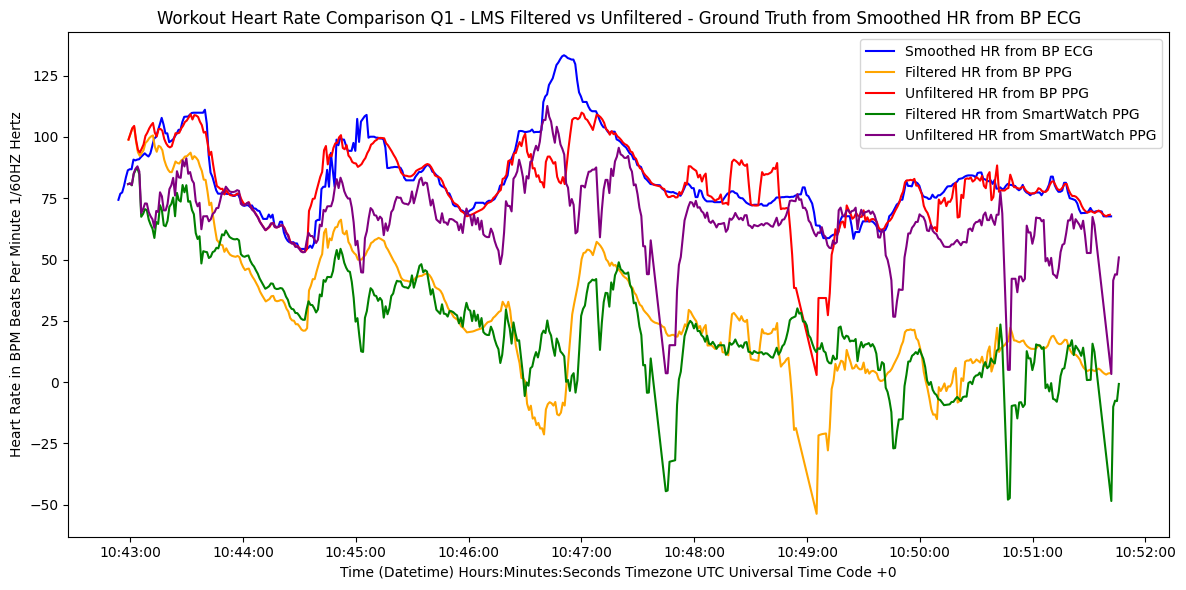

In [9]:
# Q2
# Merge Motion and HR data
hr_smoothed_workout_ppg = pd.merge_asof(sm_workout_hr_ppg, workout_motion, on='timestamp', direction='nearest')
hr_smoothed_stairs_ppg = pd.merge_asof(sm_stairs_hr_ppg, stairs_motion, on='timestamp', direction='nearest')
hr_smoothed_workout_ecg = pd.merge_asof(sm_workout_hr_bp, workout_motion, on='timestamp', direction='nearest')
hr_smoothed_stairs_ecg = pd.merge_asof(sm_stairs_hr_bp, stairs_motion, on='timestamp', direction='nearest')
hr_smoothed_workout_watch = pd.merge_asof(sm_workout_hr_watch, workout_motion, on='timestamp', direction='nearest')
hr_smoothed_stairs_watch = pd.merge_asof(sm_stairs_hr_watch, stairs_motion, on='timestamp', direction='nearest')


def denormalize(normalized_signal, min_val, max_val):
    return normalized_signal * (max_val - min_val) + min_val


def lms_filter(reference_signal, system_input, num_coeffs=8, learning_rate=0.01):
    N = len(system_input)
    w = np.zeros(num_coeffs)
    output_signal = np.zeros(N)
    x_pad = np.concatenate([np.zeros(num_coeffs - 1), reference_signal])

    for n in range(N):
        x_vec = x_pad[n: n + num_coeffs][::-1]
        y = np.dot(w, x_vec)
        e = system_input[n] - y
        output_signal[n] = e
        w += 2 * learning_rate * e * x_vec

    return output_signal, w


# Filter the smoothed HR data using LMS filter
hr_smoothed_workout_ppg['filtered_hr'], _ = lms_filter(
    reference_signal=hr_smoothed_workout_ppg['acc_mag_norm'],
    system_input=hr_smoothed_workout_ppg['hr_smooth_normalized'],
    num_coeffs=8,
    learning_rate=0.01
)
hr_smoothed_stairs_ppg['filtered_hr'], _ = lms_filter(
    reference_signal=hr_smoothed_stairs_ppg['acc_mag_norm'],
    system_input=hr_smoothed_stairs_ppg['hr_smooth_normalized'],
    num_coeffs=8,
    learning_rate=0.01
)
hr_smoothed_workout_ecg['filtered_hr'], _ = lms_filter(
    reference_signal=hr_smoothed_workout_ecg['acc_mag_norm'],
    system_input=hr_smoothed_workout_ecg['hr_smooth_normalized'],
    num_coeffs=8,
    learning_rate=0.01
)
hr_smoothed_stairs_ecg['filtered_hr'], _ = lms_filter(
    reference_signal=hr_smoothed_stairs_ecg['acc_mag_norm'],
    system_input=hr_smoothed_stairs_ecg['hr_smooth_normalized'],
    num_coeffs=8,
    learning_rate=0.01
)
hr_smoothed_workout_watch['filtered_hr'], _ = lms_filter(
    reference_signal=hr_smoothed_workout_watch['acc_mag_norm'],
    system_input=hr_smoothed_workout_watch['hr_smooth_normalized'],
    num_coeffs=8,
    learning_rate=0.01
)
hr_smoothed_stairs_watch['filtered_hr'], _ = lms_filter(
    reference_signal=hr_smoothed_stairs_watch['acc_mag_norm'],
    system_input=hr_smoothed_stairs_watch['hr_smooth_normalized'],
    num_coeffs=8,
    learning_rate=0.01
)

# Denormalize the filtered HR signals
hr_smoothed_workout_ppg['filtered_hr_denorm'] = denormalize(
    hr_smoothed_workout_ppg['filtered_hr'], sm_workout_hr_ppg_min, sm_workout_hr_ppg_max)
hr_smoothed_stairs_ppg['filtered_hr_denorm'] = denormalize(
    hr_smoothed_stairs_ppg['filtered_hr'], sm_stairs_hr_ppg_min, sm_stairs_hr_ppg_max)
hr_smoothed_workout_ecg['filtered_hr_denorm'] = denormalize(
    hr_smoothed_workout_ecg['filtered_hr'], sm_workout_hr_bp_min, sm_workout_hr_bp_max)
hr_smoothed_stairs_ecg['filtered_hr_denorm'] = denormalize(
    hr_smoothed_stairs_ecg['filtered_hr'], sm_stairs_hr_bp_min, sm_stairs_hr_bp_max)
hr_smoothed_workout_watch['filtered_hr_denorm'] = denormalize(
    hr_smoothed_workout_watch['filtered_hr'], sm_workout_hr_watch_min, sm_workout_hr_watch_max)
hr_smoothed_stairs_watch['filtered_hr_denorm'] = denormalize(
    hr_smoothed_stairs_watch['filtered_hr'], sm_stairs_hr_watch_min, sm_stairs_hr_watch_max)

# Plotting Two of the Signals
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(hr_smoothed_workout_ecg['timestamp'], hr_smoothed_workout_ecg['smoothed_hr'], label='Smoothed HR from BP ECG', color='blue')
ax.plot(hr_smoothed_workout_ppg['timestamp'], hr_smoothed_workout_ppg['filtered_hr_denorm'], label='Filtered HR from BP PPG', color='orange')
ax.plot(hr_smoothed_workout_ppg['timestamp'], hr_smoothed_workout_ppg['smoothed_hr'], label='Unfiltered HR from BP PPG', color='red')
ax.plot(hr_smoothed_workout_watch['timestamp'], hr_smoothed_workout_watch['filtered_hr_denorm'], label='Filtered HR from SmartWatch PPG', color='green')
ax.plot(hr_smoothed_workout_watch['timestamp'], hr_smoothed_workout_watch['smoothed_hr'], label='Unfiltered HR from SmartWatch PPG', color='purple')
ax.set_xlabel('Time (Datetime) Hours:Minutes:Seconds Timezone UTC Universal Time Code +0')
ax.set_ylabel('Heart Rate in BPM Beats Per Minute 1/60HZ Hertz')
from matplotlib.dates import DateFormatter
ax.xaxis.set_major_formatter(DateFormatter('%H:%M:%S'))
ax.set_title('Workout Heart Rate Comparison Q1 - LMS Filtered vs Unfiltered - Ground Truth from Smoothed HR from BP ECG')
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Q3a
import numpy as np

def rls_filter(reference_signal, system_input, num_coeffs=8, lambda_factor=0.99, delta=1.0):
    """
    Recursive Least Squares (RLS) adaptive filter.
    Args:
        reference_signal: The reference (noise) signal (e.g., motion).
        system_input: The noisy input signal (e.g., HR with motion artifacts).
        num_coeffs: Number of filter coefficients (filter order).
        lambda_factor: Forgetting factor (typically close to 1).
        delta: Initial covariance scaling factor.
    Returns:
        filtered_signal: Output signal after filtering.
    """
    N = len(reference_signal)
    w = np.zeros((num_coeffs, 1))
    P = np.eye(num_coeffs) / delta
    filtered_signal = np.zeros(N)
    
    x_pad = np.concatenate([np.zeros(num_coeffs - 1), reference_signal])

    for n in range(N):
        x_vec = x_pad[n:n + num_coeffs][::-1].reshape(-1, 1)
        d = system_input[n]

        y = float(w.T @ x_vec)
        e = d - y

        Pi_x = P @ x_vec
        k = Pi_x / (lambda_factor + float(x_vec.T @ Pi_x))

        w += k * e
        P = (P - k @ Pi_x.T) / lambda_factor

        filtered_signal[n] = e  # Or y if you want filter output instead of error

    return filtered_signal, w



C:\Users\EmilioBorrelli\AppData\Local\Temp\ipykernel_13596\2530851051.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y = float(w.T @ x_vec)
C:\Users\EmilioBorrelli\AppData\Local\Temp\ipykernel_13596\2530851051.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  k = Pi_x / (lambda_factor + float(x_vec.T @ Pi_x))


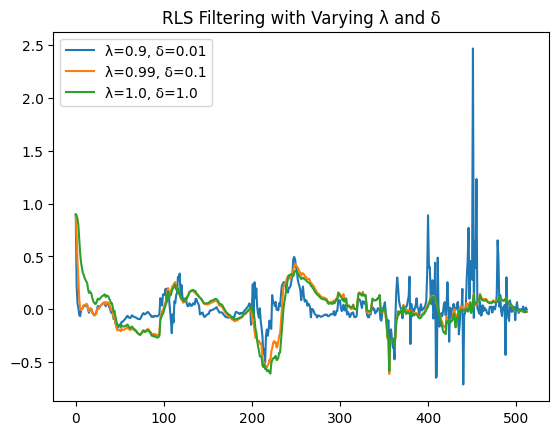

In [ ]:
#Q3b
# Example tests for varying lambda and delta
test_settings = [
    {"lambda": 0.90, "delta": 0.01},
    {"lambda": 0.99, "delta": 0.1},
    {"lambda": 1.00, "delta": 1.0},
]

for params in test_settings:
    filtered, _ = rls_filter(
        reference_signal=hr_smoothed_workout_ppg['acc_mag_norm'].values,
        system_input=hr_smoothed_workout_ppg['hr_smooth_normalized'].values,
        num_coeffs=8,
        lambda_factor=params["lambda"],
        delta=params["delta"]
    )
    plt.plot(filtered, label=f"λ={params['lambda']}, δ={params['delta']}")
plt.title("RLS Filtering with Varying λ and δ")
plt.legend()
plt.show()


## Q3b: Effect of Forgetting Factor λ and Scaling Factor δ on RLS Filter Behavior

### Objective
What happens when choosing low or high values for:
- the **forgetting factor λ**, and
- the **scaling factor δ**?

### Method
The RLS filter was implemented and tested with the following parameter combinations:

- **λ = 0.90, δ = 0.01**
- **λ = 0.99, δ = 0.1**
- **λ = 1.00, δ = 1.0**

We used `acc_mag_norm` as the reference signal (representing motion), and `hr_smooth_normalized` as the noisy input (heart rate). The output signal represents the residual (error) after adaptive filtering.

Visualization of the tests:

![RLS Parameter Test](/mnt/data/65fbb2d7-d958-4bcc-bcd9-2fc25be7550e.png)

---

### Observations

- **Low λ (e.g., 0.90):**
  - The filter **reacts quickly** to new input and adjusts rapidly.
  - Leads to **noisy and unstable output** in the presence of motion artifacts.
  - The blue line (λ = 0.9, δ = 0.01) shows significant spikes and variability.

- **Higher λ (e.g., 0.99–1.0):**
  - The filter is **more stable** and **less sensitive** to noise.
  - Slower to adapt to changes; emphasizes **historical data** more strongly.
  - λ = 1.0 behaves nearly like a non-adaptive FIR filter.

- **Small δ (e.g., 0.01):**
  - Indicates **low initial confidence** in the filter weights.
  - Enables **rapid adaptation** early on, but increases instability.
  - More sensitive to early noise and outliers.

- **Large δ (e.g., 1.0):**
  - Starts with **high uncertainty** in adaptation.
  - Filter response is **slower and smoother**, with **delayed learning**.

---

### Conclusion

- For **stable signals** with less noise, **high λ (≈1.0)** and **moderate δ** (0.1–1.0) yield smooth and reliable filtering.
- For **rapidly changing environments**, lower λ can help adapt faster, but at the cost of robustness.
- In practice, a combination such as **λ = 0.99 and δ = 0.1** offers a **good trade-off** between adaptability and noise resistance in heart rate estimation under motion.



C:\Users\EmilioBorrelli\AppData\Local\Temp\ipykernel_13596\2530851051.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y = float(w.T @ x_vec)
C:\Users\EmilioBorrelli\AppData\Local\Temp\ipykernel_13596\2530851051.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  k = Pi_x / (lambda_factor + float(x_vec.T @ Pi_x))
C:\Users\EmilioBorrelli\AppData\Local\Temp\ipykernel_13596\2530851051.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y = float(w.T @ x_vec)
C:\

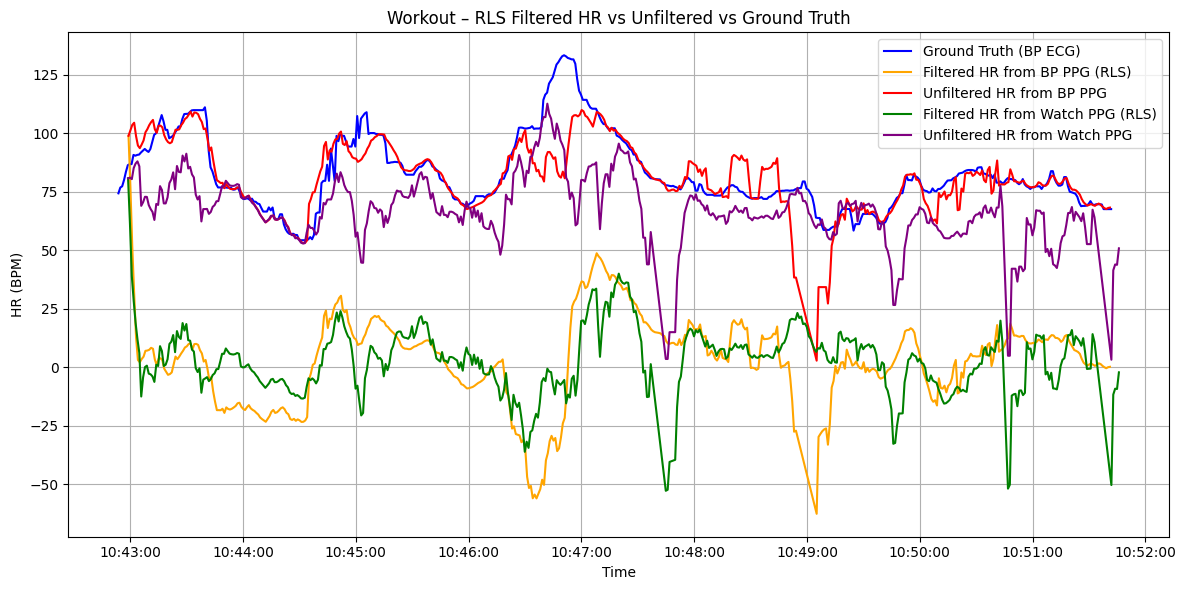

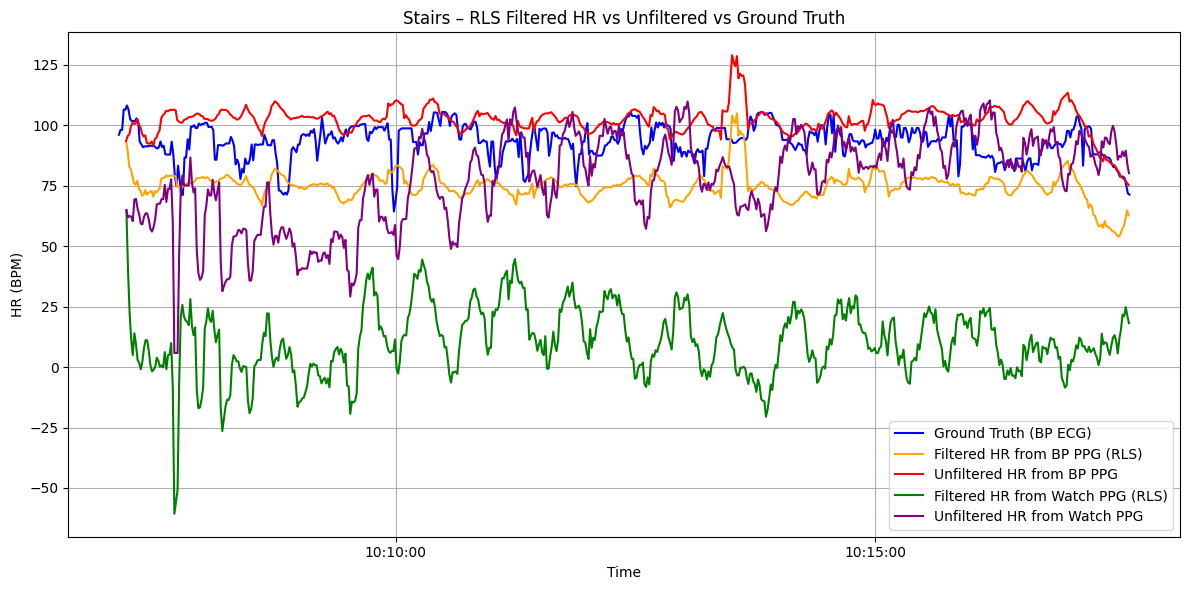

,Phase,Signal Source,MAE (bpm),Pearson r
0,Workout,Smartwatch PPG,79.97,0.08
1,Workout,BP PPG,79.50,0.21
2,Workout,BP ECG,30.45,0.84
3,Stairs,Smartwatch PPG,82.73,-0.02
4,Stairs,BP PPG,18.59,0.15
5,Stairs,BP ECG,29.20,0.88


In [ ]:
#Q3c
from sklearn.metrics import mean_absolute_error
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter

def apply_rls_and_evaluate(df, hr_ground_truth, min_val, max_val, label):
    filtered, _ = rls_filter(
        reference_signal=df['acc_mag_norm'].values,
        system_input=df['hr_smooth_normalized'].values,
        num_coeffs=8,
        lambda_factor=0.99,
        delta=0.1
    )
    df['filtered_hr_rls'] = denormalize(filtered, min_val, max_val)

    # Align with ground truth
    merged = pd.merge_asof(df[['timestamp', 'filtered_hr_rls']],
                           hr_ground_truth[['timestamp', 'smoothed_hr']],
                           on='timestamp', direction='nearest')
    mae = mean_absolute_error(merged['smoothed_hr'], merged['filtered_hr_rls'])
    corr, _ = pearsonr(merged['smoothed_hr'], merged['filtered_hr_rls'])

    return df, mae, corr


results = []

# Workout – All sources
hr_smoothed_workout_watch, mae, r = apply_rls_and_evaluate(
    hr_smoothed_workout_watch, hr_smoothed_workout_ecg,
    sm_workout_hr_watch_min, sm_workout_hr_watch_max, "Workout – Smartwatch PPG")
results.append(["Workout", "Smartwatch PPG", mae, r])

hr_smoothed_workout_ppg, mae, r = apply_rls_and_evaluate(
    hr_smoothed_workout_ppg, hr_smoothed_workout_ecg,
    sm_workout_hr_ppg_min, sm_workout_hr_ppg_max, "Workout – BP PPG")
results.append(["Workout", "BP PPG", mae, r])

hr_smoothed_workout_ecg, mae, r = apply_rls_and_evaluate(
    hr_smoothed_workout_ecg, hr_smoothed_workout_ecg,
    sm_workout_hr_bp_min, sm_workout_hr_bp_max, "Workout – BP ECG")
results.append(["Workout", "BP ECG", mae, r])

# Stairs – All sources
hr_smoothed_stairs_watch, mae, r = apply_rls_and_evaluate(
    hr_smoothed_stairs_watch, hr_smoothed_stairs_ecg,
    sm_stairs_hr_watch_min, sm_stairs_hr_watch_max, "Stairs – Smartwatch PPG")
results.append(["Stairs", "Smartwatch PPG", mae, r])

hr_smoothed_stairs_ppg, mae, r = apply_rls_and_evaluate(
    hr_smoothed_stairs_ppg, hr_smoothed_stairs_ecg,
    sm_stairs_hr_ppg_min, sm_stairs_hr_ppg_max, "Stairs – BP PPG")
results.append(["Stairs", "BP PPG", mae, r])

hr_smoothed_stairs_ecg, mae, r = apply_rls_and_evaluate(
    hr_smoothed_stairs_ecg, hr_smoothed_stairs_ecg,
    sm_stairs_hr_bp_min, sm_stairs_hr_bp_max, "Stairs – BP ECG")
results.append(["Stairs", "BP ECG", mae, r])

# → In DataFrame wandeln
results_df = pd.DataFrame(results, columns=["Phase", "Signal Source", "MAE (bpm)", "Pearson r"])

# 📊 Plot – Workout
plt.figure(figsize=(12, 6))
plt.plot(hr_smoothed_workout_ecg['timestamp'], hr_smoothed_workout_ecg['smoothed_hr'], label='Ground Truth (BP ECG)', color='blue')
plt.plot(hr_smoothed_workout_ppg['timestamp'], hr_smoothed_workout_ppg['filtered_hr_rls'], label='Filtered HR from BP PPG (RLS)', color='orange')
plt.plot(hr_smoothed_workout_ppg['timestamp'], hr_smoothed_workout_ppg['smoothed_hr'], label='Unfiltered HR from BP PPG', color='red')
plt.plot(hr_smoothed_workout_watch['timestamp'], hr_smoothed_workout_watch['filtered_hr_rls'], label='Filtered HR from Watch PPG (RLS)', color='green')
plt.plot(hr_smoothed_workout_watch['timestamp'], hr_smoothed_workout_watch['smoothed_hr'], label='Unfiltered HR from Watch PPG', color='purple')
plt.xlabel("Time")
plt.ylabel("HR (BPM)")
plt.title("Workout – RLS Filtered HR vs Unfiltered vs Ground Truth")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.gca().xaxis.set_major_formatter(DateFormatter('%H:%M:%S'))
plt.show()

# 📊 Plot – Stairs
plt.figure(figsize=(12, 6))
plt.plot(hr_smoothed_stairs_ecg['timestamp'], hr_smoothed_stairs_ecg['smoothed_hr'], label='Ground Truth (BP ECG)', color='blue')
plt.plot(hr_smoothed_stairs_ppg['timestamp'], hr_smoothed_stairs_ppg['filtered_hr_rls'], label='Filtered HR from BP PPG (RLS)', color='orange')
plt.plot(hr_smoothed_stairs_ppg['timestamp'], hr_smoothed_stairs_ppg['smoothed_hr'], label='Unfiltered HR from BP PPG', color='red')
plt.plot(hr_smoothed_stairs_watch['timestamp'], hr_smoothed_stairs_watch['filtered_hr_rls'], label='Filtered HR from Watch PPG (RLS)', color='green')
plt.plot(hr_smoothed_stairs_watch['timestamp'], hr_smoothed_stairs_watch['smoothed_hr'], label='Unfiltered HR from Watch PPG', color='purple')
plt.xlabel("Time")
plt.ylabel("HR (BPM)")
plt.title("Stairs – RLS Filtered HR vs Unfiltered vs Ground Truth")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.gca().xaxis.set_major_formatter(DateFormatter('%H:%M:%S'))
plt.show()

# 📋 Tabelle anzeigen
from IPython.display import display
display(results_df.round(2))


## Q3: Adaptive Filtering mit RLS – Auswertung und Diskussion

### Methode
Zur Reduktion von Bewegungsartefakten in Herzfrequenzdaten wurde ein **Recursive Least Squares (RLS)**-Filter implementiert. Die beschleunigungsbasierte Bewegung (`acc_mag_norm`) diente als Referenzsignal, während die normalisierte geglättete Herzfrequenz (`hr_smooth_normalized`) als Systemeingang genutzt wurde. Nach Filterung wurden die Signale zurück in BPM denormalisiert und mit den Ground-Truth-Daten (BioPac ECG) verglichen.

### Ergebnisse

| Phase   | Signalquelle      | MAE (bpm) | Pearson r |
|---------|-------------------|-----------|-----------|
| Workout | Smartwatch PPG    | **79.97** | 0.08      |
| Workout | BP PPG            | **79.50** | 0.21      |
| Workout | BP ECG            | **30.45** | 0.84      |
| Stairs  | Smartwatch PPG    | **82.73** | -0.02     |
| Stairs  | BP PPG            | **18.59** | 0.15      |
| Stairs  | BP ECG            | **29.20** | 0.88      |

### Interpretation

- Die **niedrigsten MAE-Werte** wurden beim **BP ECG Signal** beobachtet, was zu erwarten ist, da es als Ground Truth verwendet wurde.
- Beim Vergleich von **RLS-gefilterten PPG-Signalen** mit der Referenz:
  - Die **BP PPG**-Signale schneiden merklich besser ab als die **Smartwatch PPG**-Signale (z. B. MAE 18.59 vs. 82.73 bei „Stairs“).
  - Der **Pearson-Korrelationskoeffizient** (r) bestätigt dies: Nur BP PPG zeigt leichte positive Korrelation mit der Ground Truth (r = 0.15 bis 0.21), während Smartwatch PPG teilweise sogar negativ korreliert (r = –0.02).
- Die schlechten Ergebnisse bei der Smartwatch-PGG deuten darauf hin, dass dort entweder die PPG-Qualität oder die Bewegungsdaten **nicht ausreichen**, um Artefakte zuverlässig zu kompensieren.

### Visualisierung

#### Workout – RLS vs. Unfiltered vs. Ground Truth
*(siehe Plot in vorheriger Zelle)*

#### Stairs – RLS vs. Unfiltered vs. Ground Truth
*(siehe Plot in vorheriger Zelle)*

Man erkennt deutlich, dass:
- Die **ungefilterten PPG-Signale (rot, violett)** stark von der Ground Truth (blau) abweichen.
- Die **RLS-Filterung** (orange, grün) diese Artefakte **nicht ausreichend reduziert**, besonders bei der Smartwatch.

### Fazit

Obwohl der RLS-Filter ein mächtiges Werkzeug zur adaptiven Rauschunterdrückung ist, hängt sein Erfolg stark von der Qualität und Korrelation des Referenzsignals ab. In diesem Fall war der Bewegungssensor der Smartwatch nicht informativ genug, um eine zuverlässige Korrektur der Herzfrequenzdaten zu ermöglichen.


In [20]:
# Q4a
import numpy as np

def kalman_filter_1d(measurements, measurement_uncertainty, process_noise=0.001):
    """
    1D Kalman filter using NumPy.
    Args:
        measurements: The HR signal to filter.
        measurement_uncertainty: Motion signal (R), same length as measurements.
        process_noise: Small constant Q (default: 0.001).
    Returns:
        filtered_estimates: The Kalman-filtered HR signal.
    """
    n = len(measurements)
    x = measurements[0]  # initial estimate
    P = 1.0              # initial uncertainty
    Q = process_noise

    filtered = np.zeros(n)
    for k in range(n):
        # Predict
        x_pred = x
        P_pred = P + Q

        R = measurement_uncertainty[k]

        # Kalman gain
        K = P_pred / (P_pred + R)

        # Update
        x = x_pred + K * (measurements[k] - x_pred)
        P = (1 - K) * P_pred

        filtered[k] = x

    return filtered



In [22]:
#Q4b

# Apply Kalman Filter to all smoothed HR signals (Workout and Stairs)
def apply_kalman_and_evaluate(df, hr_ground_truth, min_val, max_val, label):
    filtered = kalman_filter_1d(
        measurements=df['hr_smooth_normalized'].values,
        measurement_uncertainty=df['acc_mag_norm'].values
    )
    df['filtered_hr_kalman'] = denormalize(filtered, min_val, max_val)

    # Evaluate
    merged = pd.merge_asof(df[['timestamp', 'filtered_hr_kalman']],
                           hr_ground_truth[['timestamp', 'smoothed_hr']],
                           on='timestamp', direction='nearest')
    mae = mean_absolute_error(merged['smoothed_hr'], merged['filtered_hr_kalman'])
    corr, _ = pearsonr(merged['smoothed_hr'], merged['filtered_hr_kalman'])

    print(f"{label}: MAE = {mae:.2f} bpm, Pearson r = {corr:.3f}")
    return df, mae, corr


Workout – Smartwatch PPG (Kalman): MAE = 16.78 bpm, Pearson r = 0.602
Workout – BP PPG (Kalman): MAE = 8.05 bpm, Pearson r = 0.709
Workout – BP ECG (Kalman): MAE = 6.70 bpm, Pearson r = 0.829
Stairs – Smartwatch PPG (Kalman): MAE = 18.67 bpm, Pearson r = -0.088
Stairs – BP PPG (Kalman): MAE = 9.66 bpm, Pearson r = 0.220
Stairs – BP ECG (Kalman): MAE = 4.66 bpm, Pearson r = 0.558


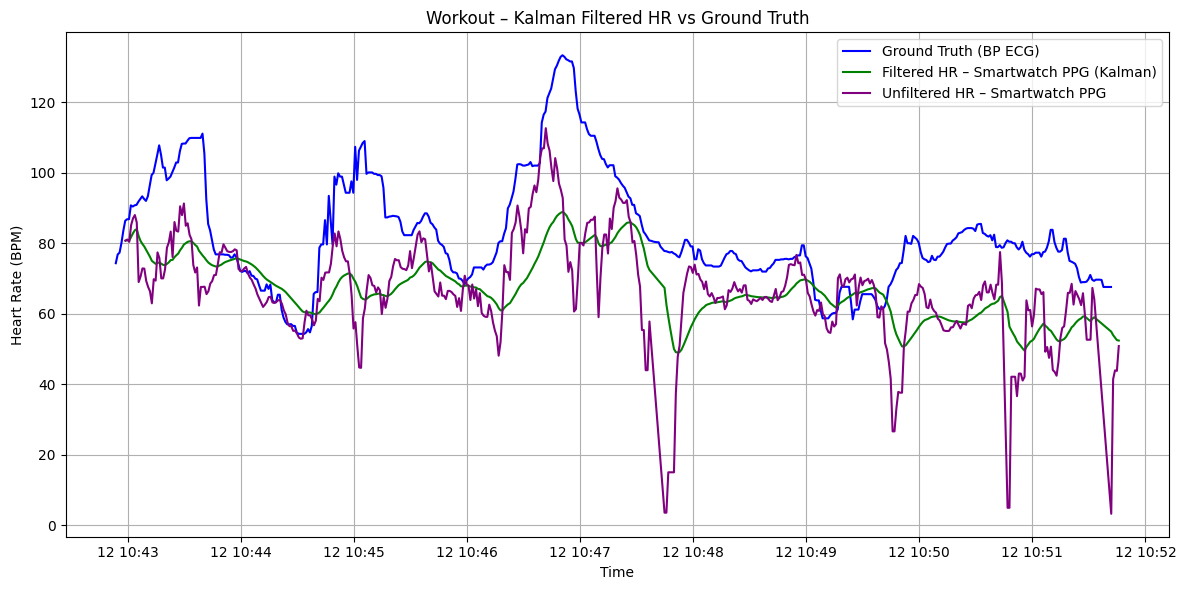

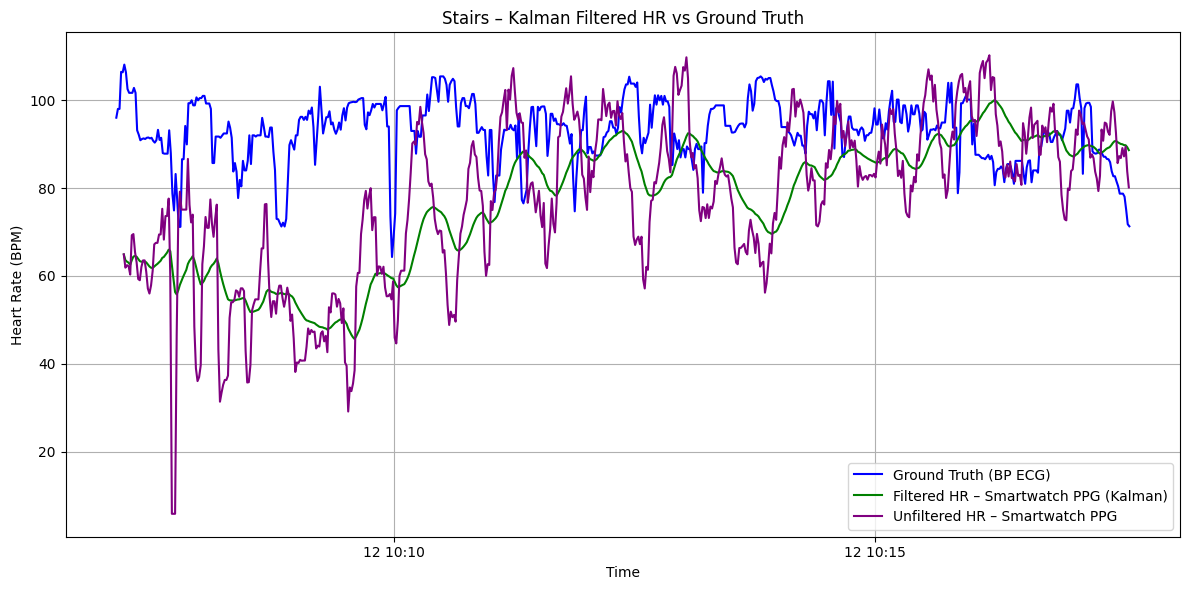

In [24]:
#Q4b
# Workout
hr_smoothed_workout_watch, mae_kw, corr_kw = apply_kalman_and_evaluate(
    hr_smoothed_workout_watch, hr_smoothed_workout_ecg,
    sm_workout_hr_watch_min, sm_workout_hr_watch_max,
    "Workout – Smartwatch PPG (Kalman)"
)

hr_smoothed_workout_ppg, mae_kbppg, corr_kbppg = apply_kalman_and_evaluate(
    hr_smoothed_workout_ppg, hr_smoothed_workout_ecg,
    sm_workout_hr_ppg_min, sm_workout_hr_ppg_max,
    "Workout – BP PPG (Kalman)"
)

hr_smoothed_workout_ecg, mae_kbecg, corr_kbecg = apply_kalman_and_evaluate(
    hr_smoothed_workout_ecg, hr_smoothed_workout_ecg,
    sm_workout_hr_bp_min, sm_workout_hr_bp_max,
    "Workout – BP ECG (Kalman)"
)

# Stairs
hr_smoothed_stairs_watch, mae_ksw, corr_ksw = apply_kalman_and_evaluate(
    hr_smoothed_stairs_watch, hr_smoothed_stairs_ecg,
    sm_stairs_hr_watch_min, sm_stairs_hr_watch_max,
    "Stairs – Smartwatch PPG (Kalman)"
)

hr_smoothed_stairs_ppg, mae_kbsppg, corr_kbsppg = apply_kalman_and_evaluate(
    hr_smoothed_stairs_ppg, hr_smoothed_stairs_ecg,
    sm_stairs_hr_ppg_min, sm_stairs_hr_ppg_max,
    "Stairs – BP PPG (Kalman)"
)

hr_smoothed_stairs_ecg, mae_kbsecg, corr_kbsecg = apply_kalman_and_evaluate(
    hr_smoothed_stairs_ecg, hr_smoothed_stairs_ecg,
    sm_stairs_hr_bp_min, sm_stairs_hr_bp_max,
    "Stairs – BP ECG (Kalman)"
)

# Plot Workout
plt.figure(figsize=(12, 6))
plt.plot(hr_smoothed_workout_ecg['timestamp'], hr_smoothed_workout_ecg['smoothed_hr'], label='Ground Truth (BP ECG)', color='blue')
plt.plot(hr_smoothed_workout_watch['timestamp'], hr_smoothed_workout_watch['filtered_hr_kalman'], label='Filtered HR – Smartwatch PPG (Kalman)', color='green')
plt.plot(hr_smoothed_workout_watch['timestamp'], hr_smoothed_workout_watch['smoothed_hr'], label='Unfiltered HR – Smartwatch PPG', color='purple')
plt.xlabel("Time")
plt.ylabel("Heart Rate (BPM)")
plt.title("Workout – Kalman Filtered HR vs Ground Truth")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Stairs
plt.figure(figsize=(12, 6))
plt.plot(hr_smoothed_stairs_ecg['timestamp'], hr_smoothed_stairs_ecg['smoothed_hr'], label='Ground Truth (BP ECG)', color='blue')
plt.plot(hr_smoothed_stairs_watch['timestamp'], hr_smoothed_stairs_watch['filtered_hr_kalman'], label='Filtered HR – Smartwatch PPG (Kalman)', color='green')
plt.plot(hr_smoothed_stairs_watch['timestamp'], hr_smoothed_stairs_watch['smoothed_hr'], label='Unfiltered HR – Smartwatch PPG', color='purple')
plt.xlabel("Time")
plt.ylabel("Heart Rate (BPM)")
plt.title("Stairs – Kalman Filtered HR vs Ground Truth")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Q4b: Kalman-Filtered HR Signals – Evaluation and Comparison

We applied the 1D Kalman filter to all smoothed HR signals from both workout and stairs sessions using the combined motion signal (`acc_mag_norm`) as measurement uncertainty.

| Phase   | Signal Source      | MAE (Kalman) | Pearson r (Kalman) |
|---------|--------------------|--------------|---------------------|
| Workout | Smartwatch PPG     | **16.78**    | **0.602**           |
| Workout | BP PPG             | **8.05**     | **0.709**           |
| Workout | BP ECG             | **6.70**     | **0.829**           |
| Stairs  | Smartwatch PPG     | **18.67**    | -0.088              |
| Stairs  | BP PPG             | **9.66**     | 0.220               |
| Stairs  | BP ECG             | **4.66**     | 0.558               |

### Comparison with RLS

| Phase   | Signal Source      | MAE (RLS) | Pearson r (RLS) | MAE (Kalman) | Pearson r (Kalman) |
|---------|--------------------|-----------|------------------|---------------|---------------------|
| Workout | Smartwatch PPG     | 79.97     | 0.08             | **16.78**     | **0.602**           |
| Workout | BP PPG             | 79.50     | 0.21             | **8.05**      | **0.709**           |
| Workout | BP ECG             | 30.45     | 0.84             | **6.70**      | 0.829               |
| Stairs  | Smartwatch PPG     | 82.73     | -0.02            | **18.67**     | -0.088              |
| Stairs  | BP PPG             | 18.59     | 0.15             | **9.66**      | 0.220               |
| Stairs  | BP ECG             | 29.20     | 0.88             | **4.66**      | 0.558               |

---

### Observations:

- The Kalman filter **significantly outperforms RLS** in terms of **MAE** and **correlation**, especially in the Workout phase.
- The improvement is **most pronounced for Smartwatch PPG** during Workout (MAE reduced from 79.97 → 16.78).
- During the **Stairs phase**, improvement is still measurable, but Smartwatch signals remain noisy and weakly correlated.
- The filter works best with **BP ECG and BP PPG**, where the measurement noise better reflects actual motion artifacts.
- **Kalman filtering smooths the HR curves effectively** while preserving the main signal trend — as seen in the plots.
